In [ ]:
import os
import random
import copy

import numpy as np
import pandas as pd

import torch
import torchvision
import torchvision.transforms as transforms
from torchvision.models import alexnet
from torchvision.models import AlexNet_Weights

from tqdm.notebook import tqdm

import wandb

import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
from google.colab import files

files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"egornovikov2005","key":"4009ea8efabcb47b4c1323756302ecd6"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [01:46<00:00, 23.0MB/s]



In [ ]:
!mkdir -p /content/chest_xray_data
!unzip -q chest-xray-pneumonia.zip -d /content/chest_xray_data/

In [ ]:
INPUT_DIR = '/content/chest_xray_data/chest_xray'

In [ ]:
class CFG:
  api = "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"
  project = "gp5-project"
  entity = None
  num_epochs = 5
  train_batch_size = 32
  test_batch_size = 64
  num_workers = 2
  lr = 0.0001
  seed = 42
  classes = ('NORMAL', 'PNEUMONIA')
  wandb = True

In [ ]:
def class2dict(f):
    return dict((name, getattr(f, name)) for name in dir(f) if not name.startswith('__'))

In [ ]:
def seed_everything(seed):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [ ]:
seed_everything(CFG.seed)

DEVICE = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
DEVICE

device(type='cuda')

In [ ]:
IMAGENET_MEAN = np.array([0.485, 0.456, 0.406])
IMAGENET_STD = np.array([0.229, 0.224, 0.225])

In [ ]:
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize(256),
        transforms.RandomCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
    ]),
    'test': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
    ])
}

In [ ]:
dataset = {
    ds: torchvision.datasets.ImageFolder(
        root=os.path.join(INPUT_DIR, ds),
        transform=data_transforms[ds]
    )
    for ds in ['train', 'val', 'test']
}

In [ ]:
dataset_size = {
    ds: len(dataset[ds])
    for ds in ['train', 'val', 'test']
}

dataset_classes = dataset['train'].classes

print('classes:', dataset_classes, '\nsize', dataset_size)

classes: ['NORMAL', 'PNEUMONIA'] 
size {'train': 5216, 'val': 16, 'test': 624}


In [ ]:
dataloader = {
    'train': torch.utils.data.DataLoader(
        dataset=dataset['train'],
        batch_size=CFG.train_batch_size,
        shuffle=True,
        num_workers=CFG.num_workers
    ),
    'val': torch.utils.data.DataLoader(
        dataset=dataset['val'],
        batch_size=CFG.test_batch_size,
        shuffle=False,
        num_workers=CFG.num_workers
    ),
    'test': torch.utils.data.DataLoader(
        dataset=dataset['test'],
        batch_size=CFG.test_batch_size,
        shuffle=False,
        num_workers=CFG.num_workers
    )
}

In [ ]:
def train_model(
    model: torch.nn.Module,
    criterion: torch.nn.Module,
    optimizer: torch.nn.Module,
    sheduler: torch.nn.Module,
    epochs: int = 5,
    WANDB: bool = False
):

    if WANDB:
        os.environ["WANDB_API_KEY"] = CFG.api
        wandb.init(
            project=CFG.project,
            entity=CFG.entity,
            reinit=True,
            config=class2dict(CFG)
        )

    losses = {'train': [], 'val': []}
    accuracies = {'train': [], 'val': []}
    recalls = {'train': [], 'val': []}

    best_model_weights = copy.deepcopy(model.state_dict())
    best_accuracy = 0.

    model = model.to(DEVICE)

    if WANDB:
        wandb.watch(model, log='all')

    pneumonia_label = dataset_classes.index('PNEUMONIA')

    progress = tqdm(range(epochs), desc='Epoch:')

    for epoch in progress:
        for phase in ['train', 'val']:

            loss_accum = 0.
            corr_accum = 0

            true_pneumonia = 0
            correct_pneumonia = 0

            model.train(mode=(phase == 'train'))

            for inputs, labels in tqdm(dataloader[phase], desc=f'Phase {phase}:'):

                inputs = inputs.to(DEVICE)
                labels = labels.to(DEVICE)

                if phase == 'train':
                    optimizer.zero_grad()

                    outp = model(inputs)
                    loss = criterion(outp, labels)

                    loss.backward()
                    optimizer.step()

                else:
                    with torch.no_grad():
                        outp = model(inputs)
                        loss = criterion(outp, labels)

                preds = torch.argmax(outp, dim=1)

                loss_accum += loss.item() * inputs.size(0)
                corr_accum += torch.sum(preds == labels).item()

                true_pneumonia += torch.sum(labels == pneumonia_label).item()
                correct_pneumonia += torch.sum(
                    (preds == pneumonia_label) & (labels == pneumonia_label)
                ).item()

            if phase == 'train':
                sheduler.step()

            epoch_loss = loss_accum / dataset_size[phase]
            epoch_accuracy = corr_accum / dataset_size[phase]

            if true_pneumonia != 0:
                epoch_recall = correct_pneumonia / true_pneumonia
            else:
                epoch_recall = 0

            losses[phase].append(epoch_loss)
            accuracies[phase].append(epoch_accuracy)
            recalls[phase].append(epoch_recall)

            progress.set_description(
                'loss: {:.4f}, acc: {:.4f}, recall: {:.4f}'.format(
                    epoch_loss,
                    epoch_accuracy,
                    epoch_recall
                )
            )

            if phase == 'val' and epoch_accuracy > best_accuracy:
                best_accuracy = epoch_accuracy
                best_model_weights = copy.deepcopy(model.state_dict())

                if WANDB:
                    wandb.log({
                        'best_val_accuracy': best_accuracy,
                        'best_val_recall': epoch_recall
                    })

            if WANDB:
                wandb.log({
                    'epoch': epoch + 1,
                    phase + '_loss': epoch_loss,
                    phase + '_accuracy': epoch_accuracy,
                    phase + '_recall': epoch_recall
                })

    model.load_state_dict(best_model_weights)

    return model, losses, accuracies, recalls

In [ ]:
model_alexnet_frozen = alexnet(weights=AlexNet_Weights.DEFAULT)

Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 165MB/s]


In [ ]:
layers_to_freeze = 6

for i, (name, param) in enumerate(model_alexnet_frozen.features.named_parameters()):
    if i < layers_to_freeze:
        param.requires_grad = False

    print(f'{name:30} {param.requires_grad}')

0.weight                       False
0.bias                         False
3.weight                       False
3.bias                         False
6.weight                       False
6.bias                         False
8.weight                       True
8.bias                         True
10.weight                      True
10.bias                        True


In [ ]:
num_in_features = 9216
num_out_features = len(dataset_classes)

model_alexnet_frozen.classifier = torch.nn.Sequential(
    torch.nn.Linear(num_in_features, 256),
    torch.nn.ReLU(),

    torch.nn.Linear(256, 64),
    torch.nn.ReLU(),

    torch.nn.Linear(64, num_out_features)
)

model_alexnet_frozen = model_alexnet_frozen.to(DEVICE)

In [ ]:
criterion = torch.nn.CrossEntropyLoss()

retrain_layers = [
    param for param in model_alexnet_frozen.parameters()
    if param.requires_grad == True
]

optimizer = torch.optim.Adam(
    retrain_layers,
    lr=CFG.lr
)

sheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=3,
    gamma=0.1
)

In [ ]:
model_alexnet_frozen, losses_alexnet_frozen, accuracies_alexnet_frozen, recalls_alexnet_frozen = train_model(
    model=model_alexnet_frozen,
    criterion=criterion,
    optimizer=optimizer,
    sheduler=sheduler,
    epochs=CFG.num_epochs,
    WANDB=CFG.wandb
)

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.
wandb: Currently logged in as: snigirev576 (snigirev576-hse) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


Epoch::   0%|          | 0/5 [00:00<?, ?it/s]

Phase train::   0%|          | 0/163 [00:00<?, ?it/s]

Phase val::   0%|          | 0/1 [00:00<?, ?it/s]

Phase train::   0%|          | 0/163 [00:00<?, ?it/s]

...

Phase val::   0%|          | 0/1 [00:00<?, ?it/s]

Phase train::   0%|          | 0/163 [00:00<?, ?it/s]

Phase val::   0%|          | 0/1 [00:00<?, ?it/s]

Phase train::   0%|          | 0/163 [00:00<?, ?it/s]

Phase val::   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
torch.save(model_alexnet_frozen.state_dict(), 'alexnet_frozen_model.pth')

if CFG.wandb:
    artifact = wandb.Artifact(
        name='alexnet_frozen_model',
        type='model'
    )

    artifact.add_file('alexnet_frozen_model.pth')
    wandb.log_artifact(artifact)

In [ ]:
def show_metrics(metrics):
    plt.figure(figsize=(12, 8))
    plt.plot(metrics['train'], label='train')
    plt.plot(metrics['val'], label='val')
    plt.grid()
    plt.legend()
    plt.show()

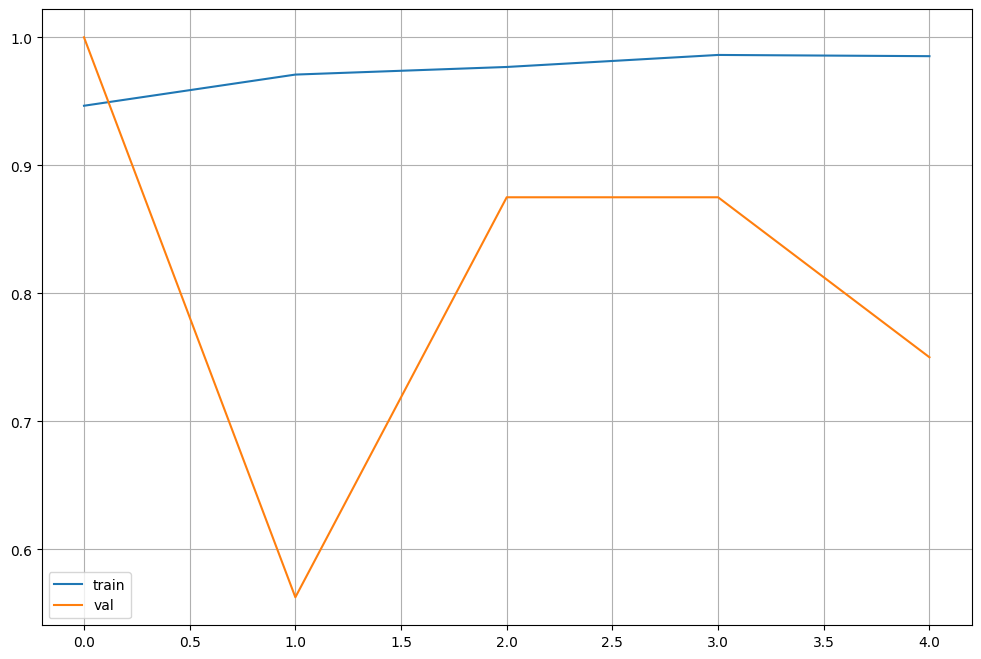

In [ ]:
show_metrics(accuracies_alexnet_frozen)

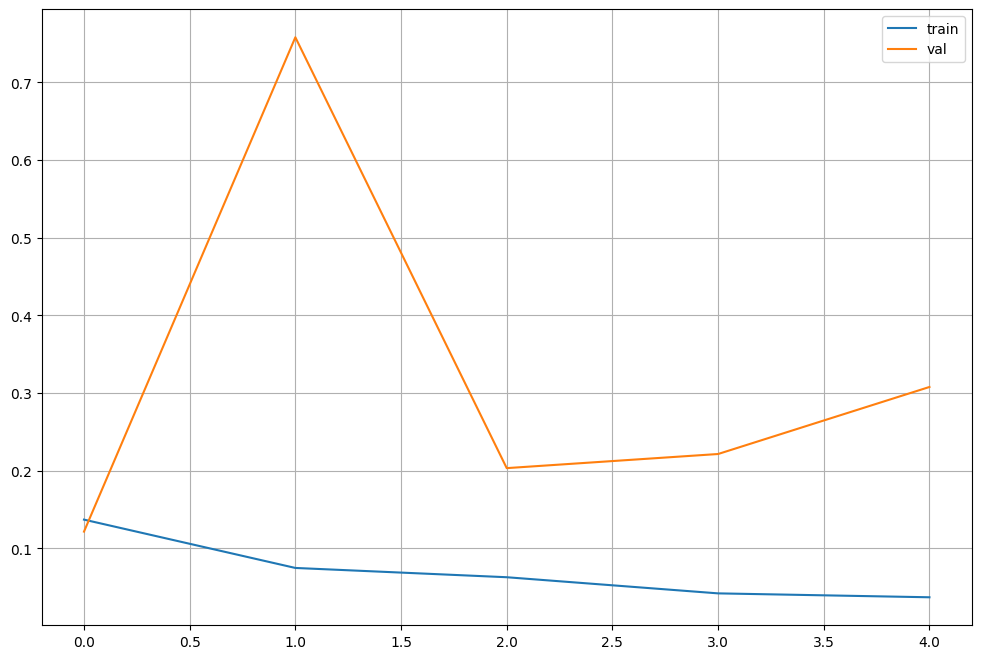

In [ ]:
show_metrics(losses_alexnet_frozen)

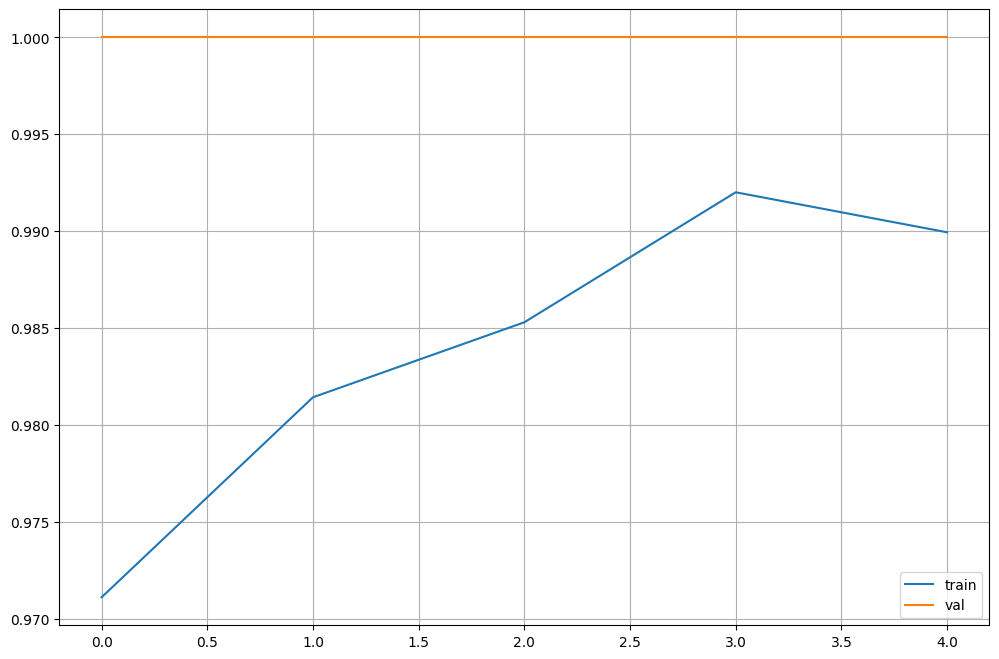

In [ ]:
show_metrics(recalls_alexnet_frozen)

In [ ]:
max(accuracies_alexnet_frozen['val'])

1.0

In [ ]:
def test(model, device, test_loader, criterion, WANDB=False):

    model.eval()

    test_loss = 0
    correct = 0

    true_pneumonia = 0
    pred_pneumonia = 0
    correct_pneumonia = 0

    pneumonia_label = dataset_classes.index('PNEUMONIA')

    with torch.no_grad():
        for data, target in test_loader:

            data, target = data.to(device), target.to(device)

            output = model(data)
            loss = criterion(output, target)

            test_loss += loss.item() * data.size(0)

            pred = output.argmax(dim=1)

            correct += torch.sum(pred == target).item()

            true_pneumonia += torch.sum(target == pneumonia_label).item()
            pred_pneumonia += torch.sum(pred == pneumonia_label).item()
            correct_pneumonia += torch.sum(
                (pred == pneumonia_label) & (target == pneumonia_label)
            ).item()

    test_loss = test_loss / len(test_loader.dataset)
    test_accuracy = correct / len(test_loader.dataset)

    if pred_pneumonia != 0:
        test_precision = correct_pneumonia / pred_pneumonia
    else:
        test_precision = 0

    if true_pneumonia != 0:
        test_recall = correct_pneumonia / true_pneumonia
    else:
        test_recall = 0

    if test_precision + test_recall != 0:
        test_f1 = 2 * test_precision * test_recall / (test_precision + test_recall)
    else:
        test_f1 = 0

    tqdm.write('Test set: Average loss: {:.4f}, Accuracy: {:.2f}%'.format(
        test_loss,
        100. * test_accuracy
    ))

    print('Test precision:', round(test_precision, 4))
    print('Test recall:', round(test_recall, 4))
    print('Test F1-score:', round(test_f1, 4))

    if WANDB:
        wandb.log({
            'test_loss': test_loss,
            'test_accuracy': test_accuracy,
            'test_precision': test_precision,
            'test_recall': test_recall,
            'test_f1': test_f1
        })

    return test_loss, test_accuracy, test_precision, test_recall, test_f1

In [ ]:
test_loss_alexnet, test_accuracy_alexnet, test_precision_alexnet, test_recall_alexnet, test_f1_alexnet = test(
    model=model_alexnet_frozen,
    device=DEVICE,
    test_loader=dataloader['test'],
    criterion=criterion,
    WANDB=CFG.wandb
)

Test set: Average loss: 0.3995, Accuracy: 87.66%
Test precision: 0.8425
Test recall: 0.9872
Test F1-score: 0.9091


In [ ]:
metrics_result_alexnet = pd.DataFrame({
    'metric': ['Accuracy', 'Precision', 'Recall', 'F1-score'],
    'value': [
        test_accuracy_alexnet,
        test_precision_alexnet,
        test_recall_alexnet,
        test_f1_alexnet
    ]
})

metrics_result_alexnet

,metric,value
0,Accuracy,0.876603
1,Precision,0.842451
2,Recall,0.987179
3,F1-score,0.909091


Доп источники:
https://colab.research.google.com/github/corrieann/kaggle/blob/master/kaggle_api_in_colab.ipynb

https://docs.pytorch.org/tutorials/beginner/saving_loading_models.html

https://docs.wandb.ai/models/artifacts